# Day 08. Exercise 05
# Clustering

## 0. Imports

In [84]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

## 1. Preprocessing

1. Read the file [`regression.csv`](https://drive.google.com/file/d/1fzOPkuXoxLleOsvNVCT0m-LKxlid33ma/view?usp=sharing) to a dataframe.
2. Remove the `pageviews`, we will cluster the users only by the number of the commits and their average difference.

In [85]:
# !gdown 1fzOPkuXoxLleOsvNVCT0m-LKxlid33ma -O '../data/regression.csv'

In [86]:
df = pd.read_csv('../data/regression.csv')
df.drop(['pageviews', 'uid'], axis = 1, inplace=True)
df.head()

,num_commits,AVG(diff)
0,62,-64.400000
1,20,-74.800000
2,61,-159.000000
3,51,-61.600000
4,5,-5.666667


## 2. KMeans

1. Check the documentation about how this algorithm works.
2. Use this algorithm to create clusters, use `random_state=21` and `n_clusters=3`.
3. Visualize the data on a `scatter plot`.
4. Try different values of `n_clusters` and see how your plot will change.
5. Calculate the `silhouette_score` (check the docs about the metric).

In [87]:
km = KMeans(random_state=21, n_clusters=3)
clusters_km = pd.Series(km.fit_predict(df))
col_3 = {"0": "black", "1": "purple", "2": 'orange'}
silhouette_score(df, clusters_km)

0.4454402135233297

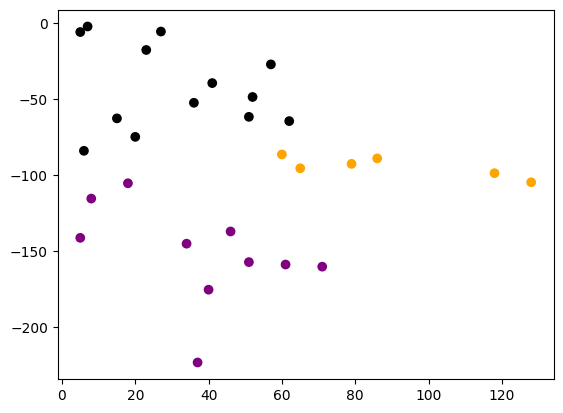

In [88]:
plt.scatter(df['num_commits'], df['AVG(diff)'], c=clusters_km.astype(str).map(col_3))

0.41503879936268956

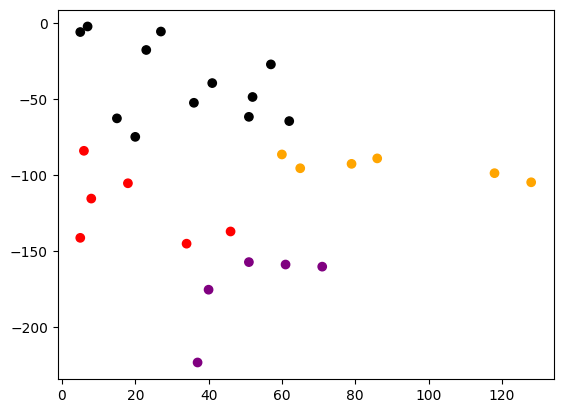

In [89]:
km = KMeans(random_state=21, n_clusters=4)
clusters_km = pd.Series(km.fit_predict(df))
col_4 = {"0": "black", "1": "purple", "2": 'orange', "3": "red"}
plt.scatter(df['num_commits'], df['AVG(diff)'], c=clusters_km.astype(str).map(col_4))
silhouette_score(df, clusters_km)

0.3521030626149593

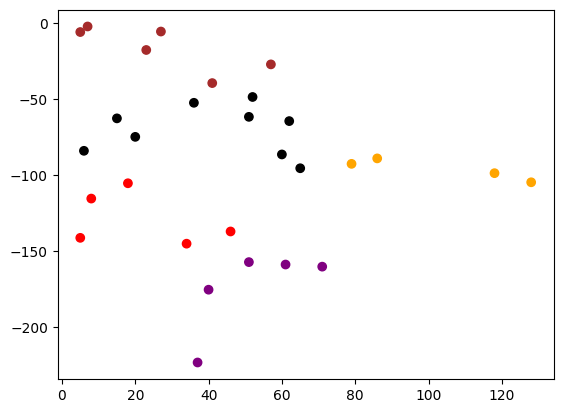

In [90]:
km = KMeans(random_state=21, n_clusters=5)
clusters_km = pd.Series(km.fit_predict(df))
col_5 = {"0": "black", "1": "purple", "2": 'orange', "3": "red", "4": 'brown'}
plt.scatter(df['num_commits'], df['AVG(diff)'], c=clusters_km.astype(str).map(col_5))
silhouette_score(df, clusters_km)

## 3. DBSCAN

1. Check the documentation about how this algorithm works.
2. Use this algorithm to create clusters with `eps=20` and `min_samples=2`.
3. Visualize the data on a `scatter plot`.
4. Try different values of `eps` and `min_samples` and see how your plot will change.
5. Calculate the `silhouette_score` (check the docs about the metric).

0.38339641455696616

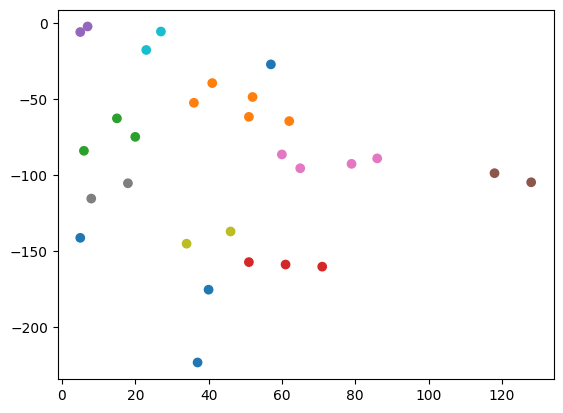

In [91]:
db = DBSCAN(eps = 20, min_samples= 2)
clusters_db = pd.Series(db.fit_predict(df))
n_clusters = len(np.unique(clusters_db))
plt.scatter(df['num_commits'], df['AVG(diff)'], c=clusters_db, cmap='tab10')
silhouette_score(df, clusters_db)

0.37939165508577244

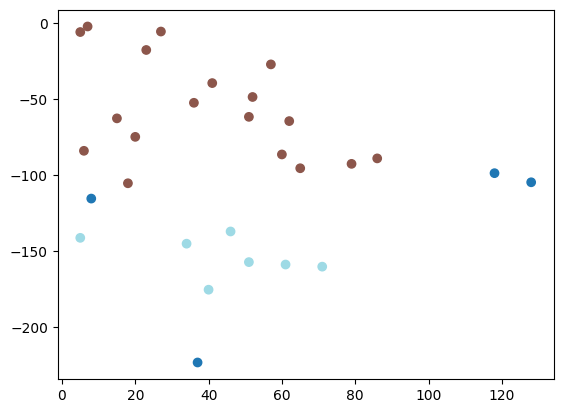

In [92]:
db = DBSCAN(eps = 30, min_samples= 4)
clusters_db = pd.Series(db.fit_predict(df))
n_clusters = len(np.unique(clusters_db))
plt.scatter(df['num_commits'], df['AVG(diff)'], c=clusters_db, cmap='tab20')
silhouette_score(df, clusters_db)

-0.07923479818777455

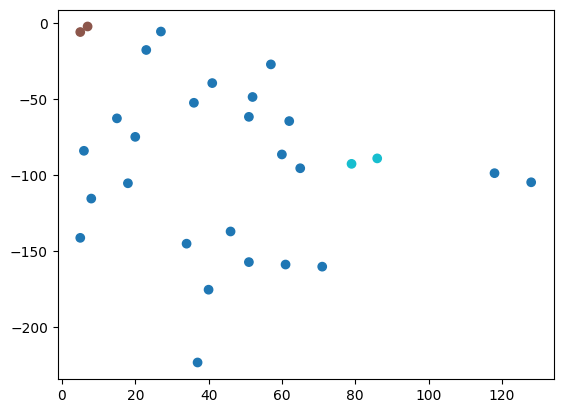

In [93]:
db = DBSCAN(eps = 10, min_samples= 2)
clusters_db = pd.Series(db.fit_predict(df))
n_clusters = len(np.unique(clusters_db))
plt.scatter(df['num_commits'], df['AVG(diff)'], c=clusters_db, cmap='tab10')
silhouette_score(df, clusters_db)

## 4. Hierarchical (AgglomerativeClustering)

1. Use this algorithm to create clusters with `n_clusters=5`.
2. Visualize the data on a `scatter plot`.
3. Try different values of `n_clusters` and see how your plot will change.
4. Calculate the `silhouette_score`.
5. Visualize the `dendrogram`.

0.46383015199381467

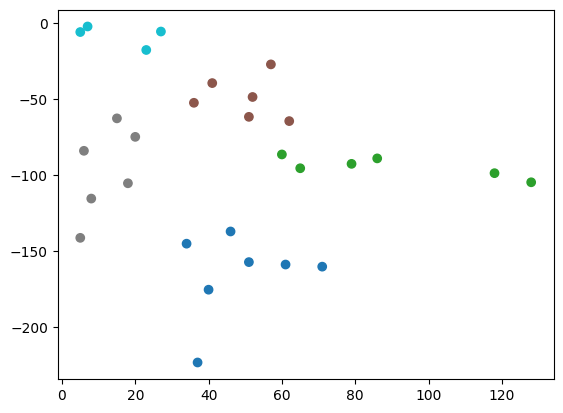

In [94]:
ac = AgglomerativeClustering(n_clusters=5)
clusters_ac = pd.Series(ac.fit_predict(df))
n_clusters = len(np.unique(clusters_ac))
plt.scatter(df['num_commits'], df['AVG(diff)'], c=clusters_ac, cmap='tab10')
silhouette_score(df, clusters_ac)

0.5077985556562201

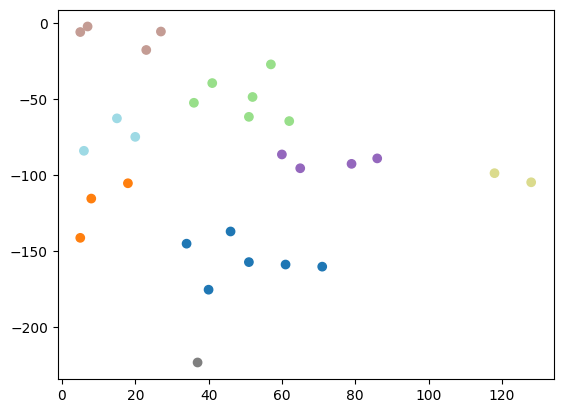

In [95]:
ac = AgglomerativeClustering(n_clusters=8)
clusters_ac = pd.Series(ac.fit_predict(df))
n_clusters = len(np.unique(clusters_ac))
plt.scatter(df['num_commits'], df['AVG(diff)'], c=clusters_ac, cmap='tab20')
silhouette_score(df, clusters_ac)

0.35902490572221984

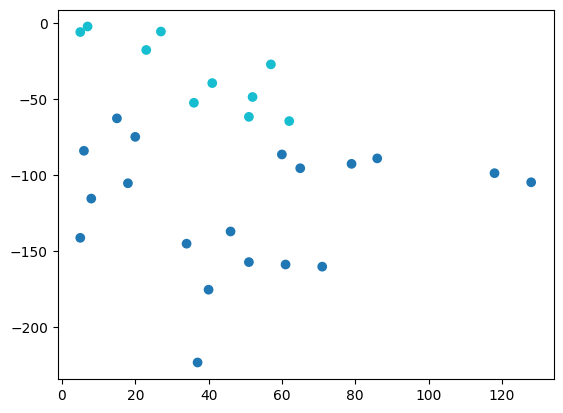

In [96]:
ac = AgglomerativeClustering(n_clusters=2)
clusters_ac = pd.Series(ac.fit_predict(df))
n_clusters = len(np.unique(clusters_ac))
plt.scatter(df['num_commits'], df['AVG(diff)'], c=clusters_ac, cmap='tab10')
silhouette_score(df, clusters_ac)

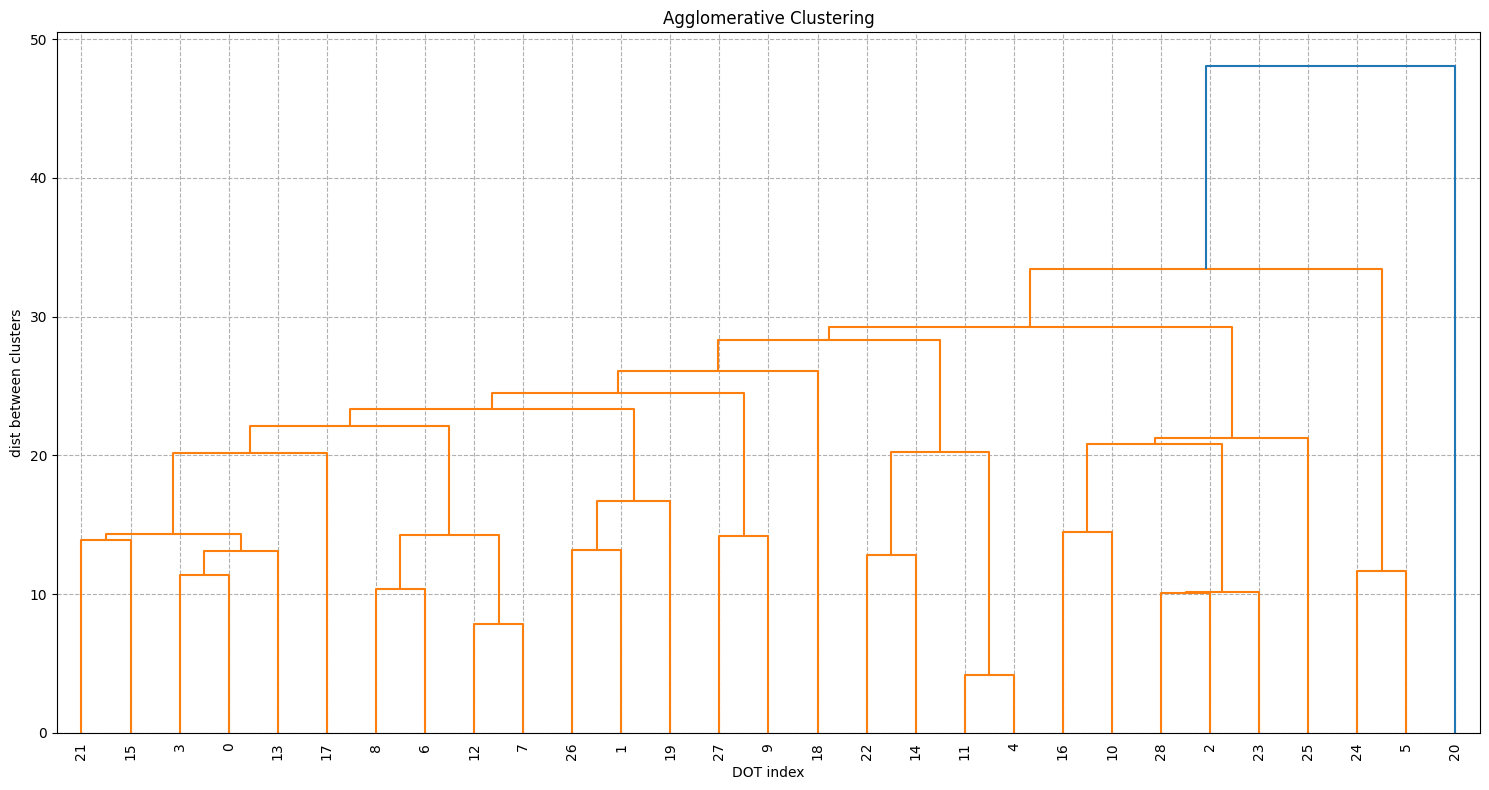

In [97]:
Z = linkage(df)
plt.figure(figsize=(15, 8))
dendrogram(Z,
           orientation='top',
           labels=range(len(df)),
           distance_sort='descending',
           show_leaf_counts=True,
           leaf_rotation=90) 
plt.title('Agglomerative Clustering')
plt.xlabel('DOT index')
plt.ylabel('dist between clusters')
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

## 5. Function

Write a function that:
1. Takes as arguments: model class of clustering, its parameters, the name of the parameter for optimization, the range of the parameter values to try.
2. Tries different values from the given parameter range and calculates the `silhouette_score` for each value from the range.
3. Finds out the best value for the parameter in the range.
4. Returns two subplots:


- - the first shows how the `silhouette_score` changes depending on the value of the parameter,
- - the second visualizes the data on a `scatter plot` using the clustering model with the best value of the parameter.

In [98]:
def optimize_clustering_parameter(model_class, df, param_name, param_range, **model_kwargs):
    scores = []
    
    for value in param_range:
        params = {param_name: value, **model_kwargs}
        model = model_class(**params)
        clusters = model.fit_predict(df)
        
        if len(np.unique(clusters)) > 1:
            score = silhouette_score(df, clusters)
        else:
            score = -1
        scores.append(score)
    
    best_idx = np.argmax(scores)
    best_value = param_range[best_idx]
    best_score = scores[best_idx]
    
    best_model = model_class(**{param_name: best_value, **model_kwargs})
    best_clusters = best_model.fit_predict(df)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))
    
    ax1.plot(param_range, scores, 'bo-')
    ax1.axvline(best_value, color='purple', linestyle = '--')
    ax1.set_xlabel(param_name)
    ax1.set_ylabel('Silhouette Score')
    ax1.set_title(f'Best {param_name}: {best_value}\nScore: {best_score:.4f}')
    ax1.grid(True, alpha=0.3)
    
    ax2.scatter(df.iloc[:, 0], df.iloc[:, 1], c=best_clusters, cmap='jet')
    ax2.set_xlabel(df.columns[0])
    ax2.set_ylabel(df.columns[1])
    ax2.set_title(f'Clustering (best {param_name})')
    
    plt.tight_layout()
    return fig, best_value, best_score

(<Figure size 1200x800 with 2 Axes>, 8, 0.48638087320227846)

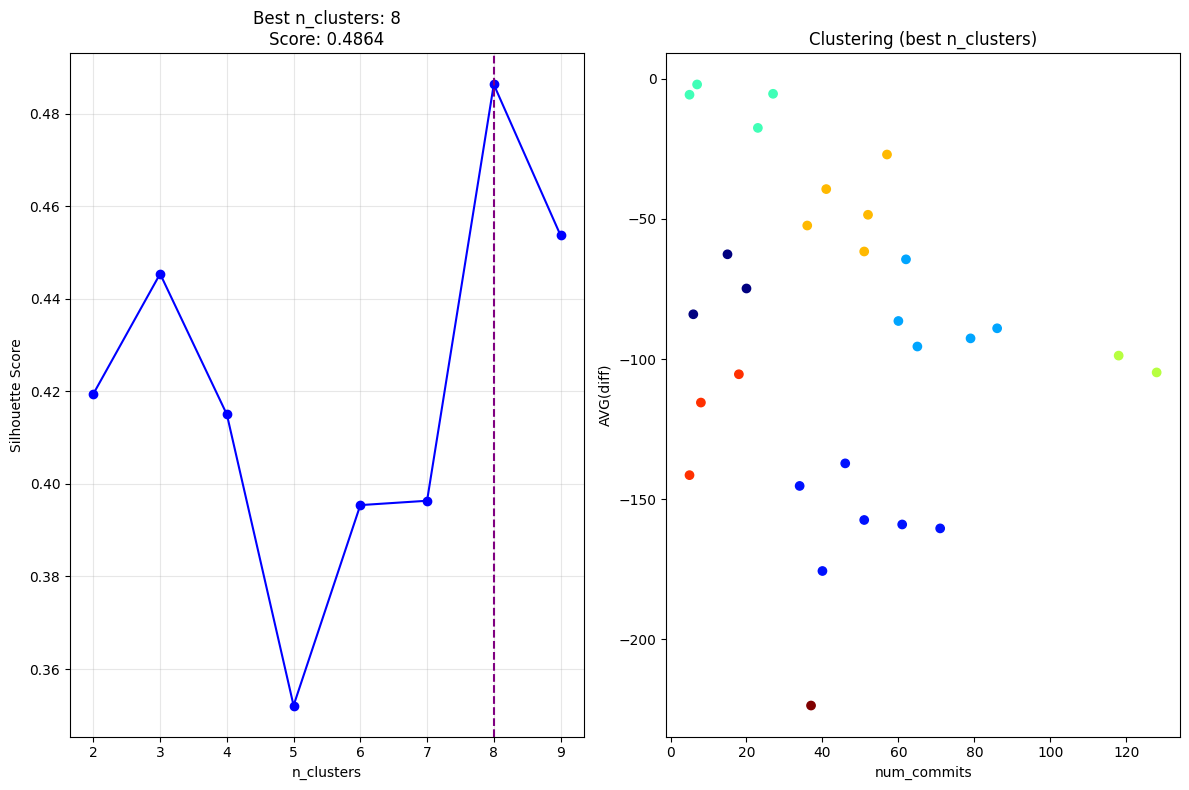

In [99]:
optimize_clustering_parameter(KMeans, df, 'n_clusters', range(2,10), random_state=21)

(<Figure size 1200x800 with 2 Axes>, 22, 0.4794129092034348)

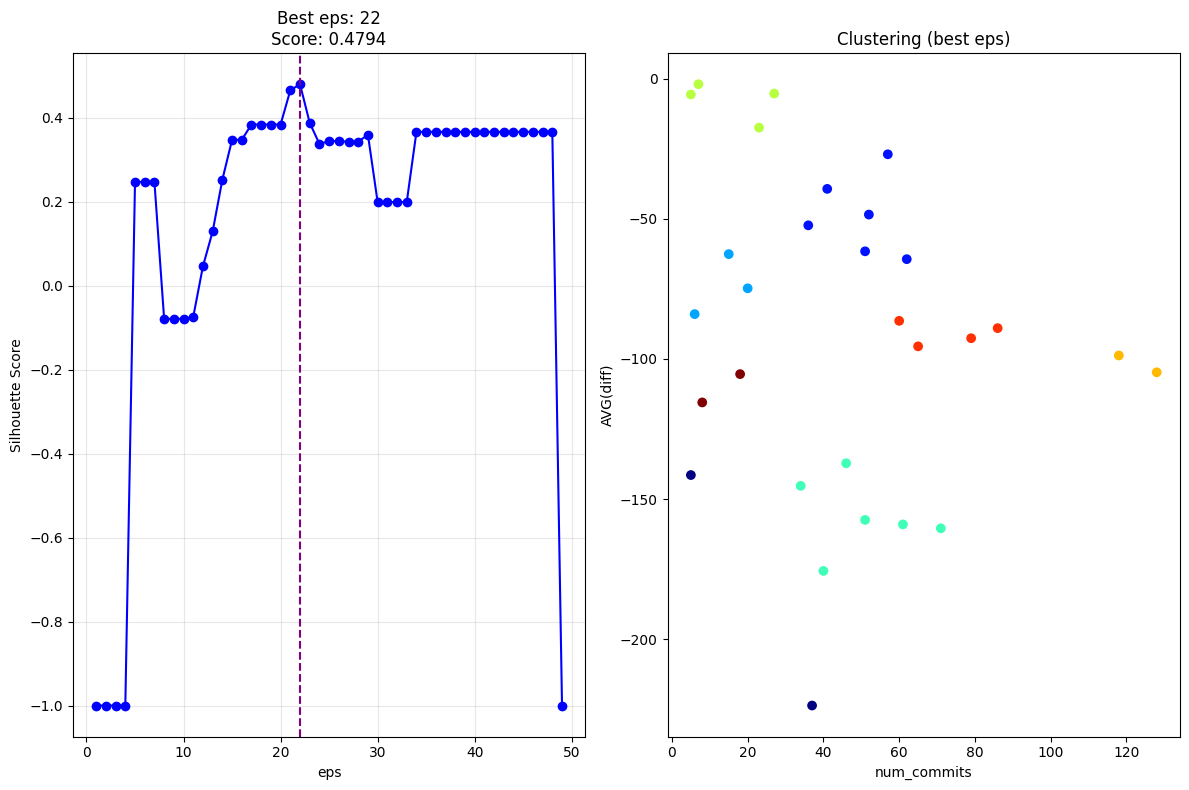

In [100]:
optimize_clustering_parameter(DBSCAN, df, 'eps', range(1,50), min_samples = 2)

(<Figure size 1200x800 with 2 Axes>, 1, 0.43224836654245735)

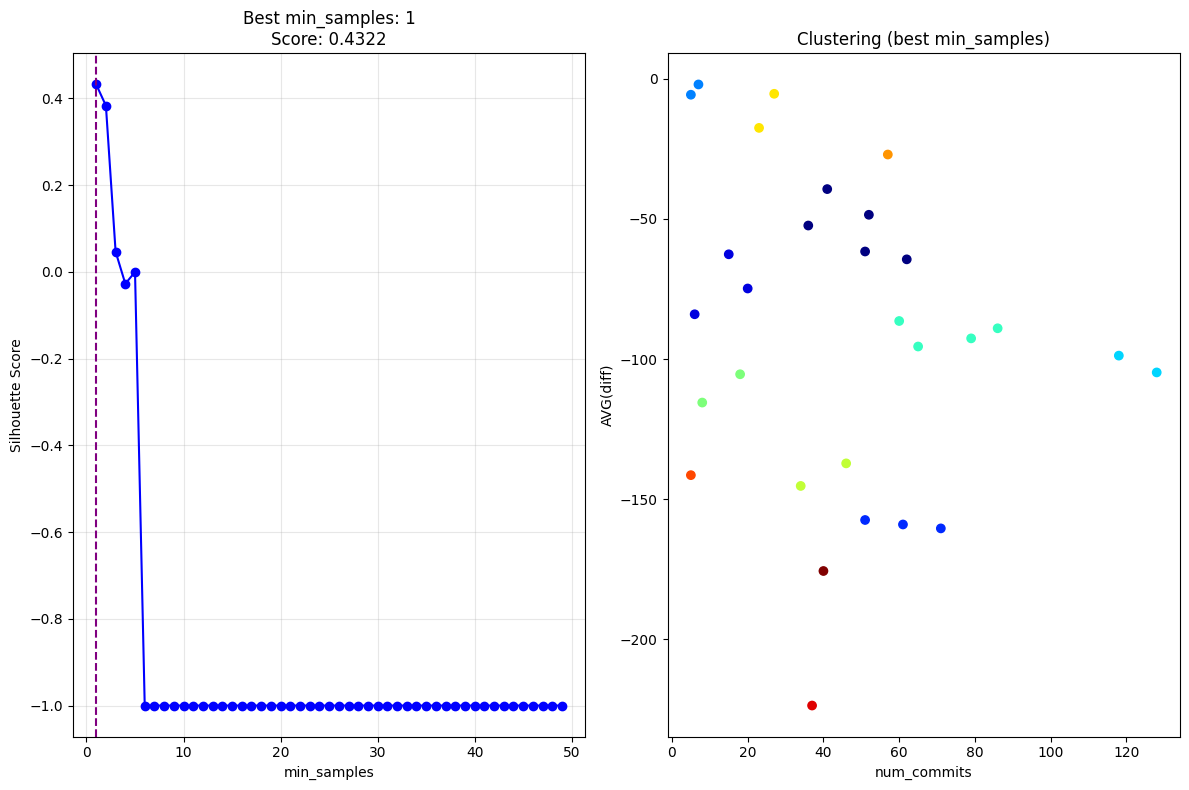

In [101]:
optimize_clustering_parameter(DBSCAN, df, 'min_samples', range(1,50), eps = 20)

(<Figure size 1200x800 with 2 Axes>, 8, 0.5077985556562201)

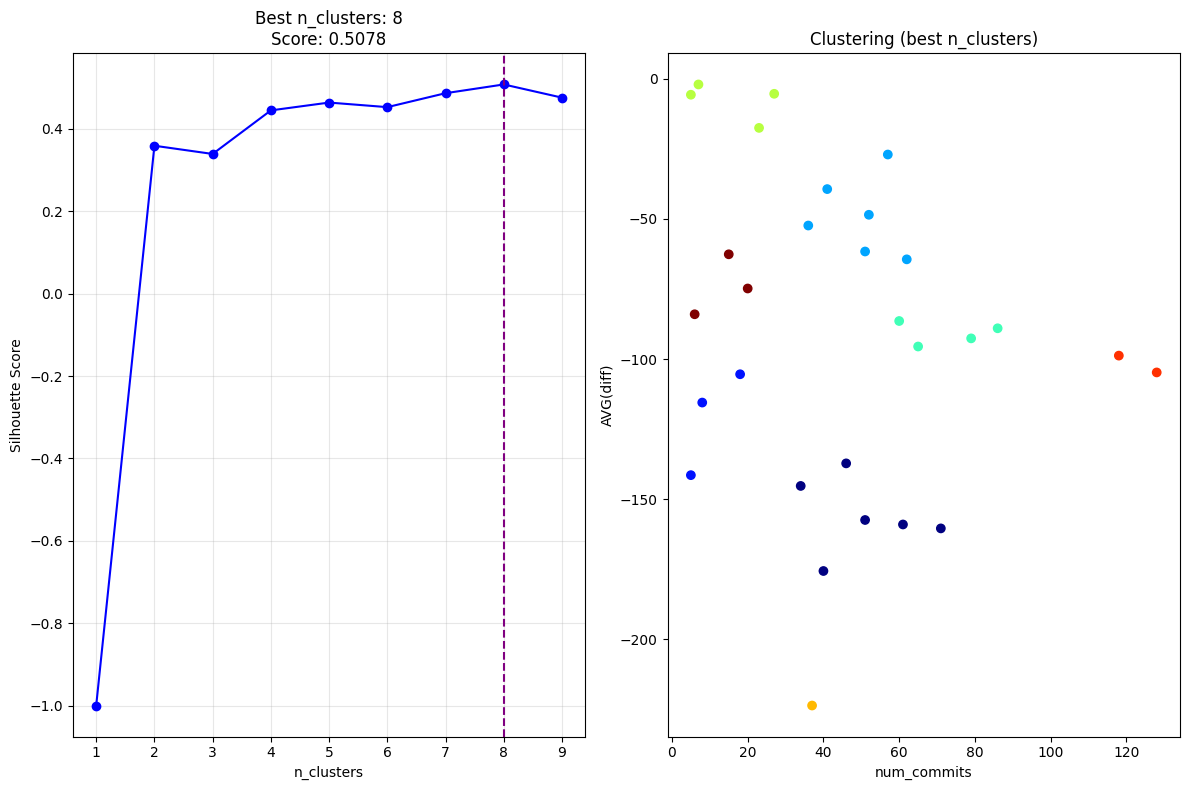

In [102]:
optimize_clustering_parameter(AgglomerativeClustering, df, 'n_clusters', range(1,10))